In [1]:
import matplotlib.pyplot as plt
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
import torch.nn.functional as F
import cv2
import os
from tqdm import tqdm

from torchvision.transforms import v2

from utils import preprocessing_remove_lines, preprocessing_split_by_characters

In [2]:
source_folder = "test/"
captcha_files = [f for f in os.listdir(source_folder) if f.lower().endswith(".png")]
if not captcha_files:
    raise FileNotFoundError(f"No Captcha files found in {source_folder}")

# Setup GPU

In [3]:
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
print(device)

cuda:0


# Setup Character Classification ANN Model
The model class must be same as the trained model, probably should be moved to its own .py file

In [4]:
char_classes = {
    "0": 0,
    "1": 1,
    "2": 2,
    "3": 3,
    "4": 4,
    "5": 5,
    "6": 6,
    "7": 7,
    "8": 8,
    "9": 9,
    "a": 10,
    "b": 11,
    "c": 12,
    "d": 13,
    "e": 14,
    "f": 15,
    "g": 16,
    "h": 17,
    "i": 18,
    "j": 19,
    "k": 20,
    "l": 21,
    "m": 22,
    "n": 23,
    "o": 24,
    "p": 25,
    "q": 26,
    "r": 27,
    "s": 28,
    "t": 29,
    "u": 30,
    "v": 31,
    "w": 32,
    "x": 33,
    "y": 34,
    "z": 35,
}
num_classes = len(char_classes)
print(num_classes)

# Add your Neural Network here (if using NN)

class Model(nn.Module):
    # Convenience function for getting the no. of parameters after convolution
    def get_num_features_after_conv(self, shape):
        # Pass a dummy input through the conv layers
        x = torch.zeros(1, 1, *shape)
        x = self.pool(F.relu(self.bn1(self.conv1(x))))
        x = self.pool(F.relu(self.bn2(self.conv2(x))))
        x = self.pool(F.relu(self.bn3(self.conv3(x))))
        #x = F.relu(self.conv4(x))
        return x.numel()  # total number of features after flattening
    
    def __init__(self):
        super().__init__()
        self.conv1 = nn.Conv2d(1, 32, 5)
        self.bn1 = nn.BatchNorm2d(32)
        self.pool = nn.MaxPool2d(2, 2)
        self.conv2 = nn.Conv2d(32, 64, 3)
        self.bn2 = nn.BatchNorm2d(64)
        self.conv3 = nn.Conv2d(64, 64, 3)
        self.bn3 = nn.BatchNorm2d(64)
        #self.conv4 = nn.Conv2d(256, 256, 3)
        
        self.fc1 = nn.Linear(self.get_num_features_after_conv((42, 42)), 64)
        self.fc2 = nn.Linear(64, 128)
        self.fc3 = nn.Linear(128, 128)
        #self.fc4 = nn.Linear(256, 256)
        self.fc5 = nn.Linear(128, num_classes)

    def forward(self, x):
        x = self.pool(F.relu(self.bn1(self.conv1(x))))
        x = self.pool(F.relu(self.bn2(self.conv2(x))))
        x = self.pool(F.relu(self.bn3(self.conv3(x))))
        #x = F.relu(self.conv4(x))
        x = torch.flatten(x, 1) # flatten all dimensions except batch
        x = F.relu(self.fc1(x))
        x = F.relu(self.fc2(x))
        x = F.relu(self.fc3(x))
        #x = F.relu(self.fc4(x))
        x = self.fc5(x)
        return x

net = torch.load("char_classification_model.pth", map_location=device, weights_only=False)
net.to(device)
net.eval()

36


Model(
  (conv1): Conv2d(1, 32, kernel_size=(5, 5), stride=(1, 1))
  (bn1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (pool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (conv2): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1))
  (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (conv3): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1))
  (bn3): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (fc1): Linear(in_features=576, out_features=64, bias=True)
  (fc2): Linear(in_features=64, out_features=128, bias=True)
  (fc3): Linear(in_features=128, out_features=128, bias=True)
  (fc5): Linear(in_features=128, out_features=36, bias=True)
)

# Captcha Seperation

In [5]:
def process_character_image(img):
    # --- Convert to grayscale ---
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    
    # --- Invert so character = white (255), background = black (0) ---
    gray = 255 - gray
    
    # --- Threshold to make binary ---
    #_, binary = cv2.threshold(gray, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)
    
    # --- Find bounding box of character ---
    coords = cv2.findNonZero(gray)
    x, y, w, h = cv2.boundingRect(coords)
    
    # --- Crop + 3px padding ---
    pad = 3
    x1 = max(x - pad, 0)
    y1 = max(y - pad, 0)
    x2 = min(x + w + pad, gray.shape[1])
    y2 = min(y + h + pad, gray.shape[0])
    cropped = gray[y1:y2, x1:x2]

    # --- Normalize brightness: stretch intensity range to full 0–255 ---
    min_val, max_val = np.min(cropped), np.max(cropped)
    if max_val > min_val:  # avoid divide-by-zero if image is uniform
        cropped = (cropped - min_val) * (255.0 / (max_val - min_val))
        cropped = np.clip(cropped, 0, 255).astype(np.uint8)
    
    # Below: Pad or crop all letters to the same square (while avoiding stretching proportions)
    # --- Create black background ---
    target_size = 42
    canvas = np.zeros((target_size, target_size), dtype=np.uint8)
    
    # --- If cropped image is larger than 32x32, center crop it ---
    h, w = cropped.shape
    if h > target_size or w > target_size:
        # Center crop
        start_y = max((h - target_size) // 2, 0)
        start_x = max((w - target_size) // 2, 0)
        end_y = start_y + target_size
        end_x = start_x + target_size
        cropped = cropped[start_y:end_y, start_x:end_x]
        h, w = cropped.shape
    
    # --- Compute top-left position to center the image ---
    y_offset = (target_size - h) // 2
    x_offset = (target_size - w) // 2
    
    # --- Paste cropped image onto canvas ---
    canvas[y_offset:y_offset + h, x_offset:x_offset + w] = cropped

    return canvas

def split_into_char_images(img):
    img = preprocessing_remove_lines(img) # Remove lines
    num_chars, char_images = preprocessing_split_by_characters(img) # Split chars
    processed_char_images = []
    for char_img in char_images:
        processed_char_images.append(process_character_image(char_img)) 
    return processed_char_images

### Test split images

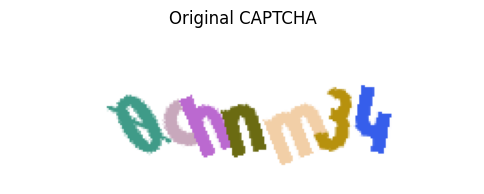

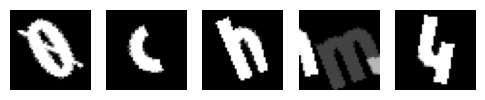

In [6]:
test_captcha_idx = 18
test_captcha = cv2.imread(os.path.join(source_folder, captcha_files[test_captcha_idx]))
test_captcha_filename = captcha_files[test_captcha_idx]
test_char_images = split_into_char_images(test_captcha)

# Display char images side by side
plt.figure(figsize=(6, 3))
plt.imshow(cv2.cvtColor(test_captcha, cv2.COLOR_BGR2RGB))  # Convert BGR → RGB
plt.title("Original CAPTCHA")
plt.axis('off')
plt.show()

plt.figure(figsize=(6, 3))
for i, char_img in enumerate(test_char_images):
    plt.subplot(1, len(test_char_images), i + 1)
    plt.imshow(char_img, cmap='gray')
    plt.axis('off')
plt.show()

# Character Detection

In [7]:
def predict(y_pred_logits): 
    # Take the index of the highest logit for each sample
    y_pred = torch.argmax(y_pred_logits, dim=1) # Note: returns a tensor
    return y_pred

def predict_single_char_image(net, img, char_classes):
    # Preprocess img with cv2 resize if incorrect size
    if img.shape[0] != 42 or img.shape[1] != 42:
        img = cv2.resize(img, (42, 42), interpolation=cv2.INTER_LINEAR)

    # Normalize and convert to tensor
    img = img.astype('float32') / 255.0
    img = np.expand_dims(img, axis=0)   # (1, 42, 42)
    img_tensor = torch.tensor(img, dtype=torch.float32).unsqueeze(0).to(device)  # (1, 1, 42, 42)

    net.eval()
    with torch.no_grad():
        output = net(img_tensor)
        predicted_class = predict(output).item()

    # Map index back to character
    inv_char_classes = {v: k for k, v in char_classes.items()}
    predicted_label = inv_char_classes[predicted_class]

    return predicted_label

def predict_single_char_image_with_variants(net, img, char_classes, variants=False, show=False):
    """
    Predicts a single character image using multiple augmentations:
    - original
    - inverted color
    - rotated -30 degrees
    - rotated +30 degrees
    Returns the most confident prediction.
    """

    # Predict single image and give prediction + confidence
    def predict_variant(img_variant):
        # Resize if needed
        if img_variant.shape[0] != 42 or img_variant.shape[1] != 42:
            img_variant = cv2.resize(img_variant, (42, 42), interpolation=cv2.INTER_LINEAR)

        # Normalize and tensorize
        img_variant = img_variant.astype('float32') / 255.0
        img_variant = np.expand_dims(img_variant, axis=0)   # (1, 42, 42)
        img_tensor = torch.tensor(img_variant, dtype=torch.float32).unsqueeze(0).to(device)  # (1, 1, 42, 42)

        # Predict logits and confidence
        net.eval()
        with torch.no_grad():
            output = net(img_tensor)
            probs = F.softmax(output, dim=1)
            confidence, predicted_class = torch.max(probs, dim=1)

        return predicted_class.item(), confidence.item()

    # If we do not want to use variants, just predict the original img
    if not variants:
        pred_idx, _ = predict_variant(img)
        # Map index to label
        inv_char_classes = {v: k for k, v in char_classes.items()}
        predicted_label = inv_char_classes[pred_idx]
        
        if show:
            plt.imshow(img, cmap='gray')
            plt.title(f"Pred: {predicted_label}")
        return predicted_label
    
    # --- Create variants ---
    variants = {
        "original": img,
        "inverted": 255 - img,
        "rot_-15": cv2.warpAffine(img, cv2.getRotationMatrix2D((img.shape[1]//2, img.shape[0]//2), -15, 1.0), (img.shape[1], img.shape[0])),
        "rot_+15": cv2.warpAffine(img, cv2.getRotationMatrix2D((img.shape[1]//2, img.shape[0]//2), 15, 1.0), (img.shape[1], img.shape[0])),
        "scale_80": cv2.warpAffine(img, cv2.getRotationMatrix2D((img.shape[1]//2, img.shape[0]//2), 0, 0.8), (img.shape[1], img.shape[0])),
    }

    # --- Evaluate each variant ---
    best_pred = None
    best_conf = -1
    best_key = None
    preds_conf = {}

    # --- Predict each variant ---
    for key, variant in variants.items():
        pred_idx, conf = predict_variant(variant)
        preds_conf[key] = (pred_idx, conf)
        if conf > best_conf:
            best_conf = conf
            best_pred = pred_idx
            best_key = key

    # Map index to label
    inv_char_classes = {v: k for k, v in char_classes.items()}
    predicted_label = inv_char_classes[best_pred]

    # --- Plot all variants side by side (if show = True) ---
    if show:
        print(f"Best prediction: {predicted_label} ({best_key}, conf={best_conf:.2f})")
        plt.figure(figsize=(12, 3))
        for i, (key, variant) in enumerate(variants.items()):
            pred_idx, conf = preds_conf[key]
            label = inv_char_classes[pred_idx]
            plt.subplot(1, len(variants), i + 1)
            plt.imshow(variant, cmap='gray')
            plt.title(f"{key}\nPred: {label}\nConf: {conf:.2f}")
            plt.axis('off')
        plt.show()

    return predicted_label

def predict_char_images(net, char_images, char_classes, show=False):
    output = []
    for char_img in char_images:
        output.append(predict_single_char_image_with_variants(net, char_img, char_classes, show))

    return output

### Test character detection

0chnm34-0.png
['q', 'c', 'h', 'h', '4']


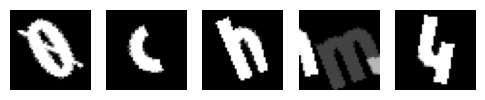

In [9]:
# Display predictions
print(test_captcha_filename)
print(predict_char_images(net, test_char_images, char_classes, show=True))

# Display char images
plt.figure(figsize=(6, 3))
for i, char_img in enumerate(test_char_images):
    plt.subplot(1, len(test_char_images), i + 1)
    plt.imshow(char_img, cmap='gray')
    plt.axis('off')
plt.show()

# Compute Metrics

### Allowance for similar characters
According to prof, captcha often has allowance for similar characters being mistaken. So we can have a metric for this as well.

In [10]:
def is_char_correct_with_allowance(input, truth):
    similars = [["o", "0"], 
               ["1", "l", "i"],
               ["9", "q"],
               ["b", "6"],
               ["2", "z"]]
    for group in similars:
        if truth in group:
            return input in group

    return input == truth

### Run Test Pipeline on Test Data

In [11]:
test_folder = "test/"
captcha_files = [f for f in os.listdir(test_folder) if f.lower().endswith(".png")]
if not captcha_files:
    raise FileNotFoundError(f"No Captcha files found in {test_folder}")

images_count = 0
wrong_char_num_count = 0
correct = 0
correct_with_allowance = 0

character_count = 0
correct_char_count = 0
correct_char_count_with_allowance = 0

for (root,dirs,files) in os.walk(test_folder,topdown=True):
    for file in tqdm(files, desc="Loading images"):
        if file.endswith('.png'):
            if file[1] == "_":
                os.remove(os.path.join(root, file))
                continue
            if file.split("-")[1].split(".png")[0] != "0": # remove any images marked wrong (train data)
                continue

            images_count += 1
            
            correct_char_array = list(file.split("-")[0])
            character_count += len(correct_char_array)
            img_path = os.path.join(root, file)
            img = cv2.imread(img_path)

            char_images = split_into_char_images(img)
            predicted_char_array = predict_char_images(net, char_images, char_classes)

            correct_char_count += sum(c1 == c2 for c1, c2 in zip(correct_char_array, predicted_char_array))
            correct_char_count_with_allowance += sum(is_char_correct_with_allowance(c1, c2) for c1, c2 in zip(correct_char_array, predicted_char_array))
            
            # Wrong number of characters
            if len(correct_char_array) != len(predicted_char_array):
                wrong_char_num_count += 1
                continue

            # All correct
            if all(c1 == c2 for c1, c2 in zip(correct_char_array, predicted_char_array)):
                correct += 1
                correct_with_allowance += 1
                continue

            # ALl correct only with allowance
            if all(is_char_correct_with_allowance(c1, c2) for c1, c2 in zip(correct_char_array, predicted_char_array)):
                correct_with_allowance += 1
                continue

print(f'Captcha count: {images_count}')
print(f'Wrong number of characters: {wrong_char_num_count} ({(wrong_char_num_count / images_count * 100):.2f}%)')
print(f'Correct: {correct} ({(correct / images_count * 100):.2f}%)')
print(f'Correct with allowance: {correct_with_allowance} ({(correct_with_allowance / images_count * 100):.2f}%)')
print("")
print(f'Total character count: {character_count}')
print(f'Correct characters: {correct_char_count} ({(correct_char_count / character_count * 100):.2f}%)')
print(f'Correct characters with allowance: {correct_char_count_with_allowance} ({(correct_char_count_with_allowance / character_count * 100):.2f}%)')

Loading images: 100%|██████████████████████████████████████████████████████████████| 2001/2001 [00:43<00:00, 46.36it/s]

Captcha count: 1999
Wrong number of characters: 93 (4.65%)
Correct: 1201 (60.08%)
Correct with allowance: 1499 (74.99%)

Total character count: 12006
Correct characters: 10600 (88.29%)
Correct characters with allowance: 11038 (91.94%)
